# PySpark Models

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
import sys

sys.path.append("../bayesian_trees")

In [3]:
import os
import socket

RUN_MODE = 'LOCAL'

if 'gdpic-srvls-session' in socket.gethostname():
    RUN_MODE = 'ServerlessSession'

print(f"Run mode is {RUN_MODE}")

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

Run mode is LOCAL


In [4]:
import logging

import numpy as np
import pandas as pd
import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from pyspark.ml.classification import (
    DecisionTreeClassifier,
    GBTClassifier,
    RandomForestClassifier
)
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.sql.types import FloatType
from bayesian_trees.tree_utils import get_log_loss, plot_performance_chart

pd.DataFrame.iteritems = pd.DataFrame.items

logger = logging.getLogger(__name__)
logging_formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
logging_file_handler = logging.FileHandler(filename="adult_census_income_pyspark.log")
logging_console_handler = logging.StreamHandler()
logging_file_handler.setFormatter(logging_formatter)
logging_console_handler.setFormatter(logging_formatter)
logging.basicConfig(handlers=[logging_console_handler, logging_file_handler], level=logging.INFO)

get_failure_probability = F.udf(lambda v: float(v[0]), FloatType())
get_success_probability = F.udf(lambda v: float(v[1]), FloatType())

In [5]:
spark_builder = SparkSession.builder.appName("adult_census_income")

if RUN_MODE == 'LOCAL':
    spark_builder = (
        spark_builder
        .config("spark.driver.memory", "2g")
        .config("spark.executor.memory", "2g")
        .config("spark.sql.shuffle.partitions", "4000")
    )
else:
    spark_builder = (
        spark_builder
        .config("spark.sql.hive.filesourcePartitionFileCacheSize", "524288000")
    )

spark = (
    spark_builder
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

sc = spark.sparkContext
sc.setLogLevel("ERROR")
logger.info(f"Spark Version: {sc.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/05 18:53:22 WARN Utils: Your hostname, leonid, resolves to a loopback address: 127.0.1.1; using 10.249.170.38 instead (on interface wlp0s20f3)
26/03/05 18:53:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/05 18:53:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2026-03-05 18:53:26,442 - __main__ - INFO - Spark Version: 4.1.1


In [6]:
LEARN_DATA_FILE = "../datasets/adult_census_income/adult.data"
TEST_DATA_FILE = "../datasets/adult_census_income/adult.test"

RAW_DATA_COLS = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]
RAW_DATA_NUMERIC_COLS = [
    "age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"
]

OUTCOMES_COLS = ["negative", "positive"]

In [7]:
raw_learn_data = pd.read_csv(
    LEARN_DATA_FILE,
    sep=", ",
    header=None,
    na_values=["?"],
    names=RAW_DATA_COLS,
    engine="python"
)
raw_learn_data["negative"] = np.where(raw_learn_data["income"] == "<=50K", 1, 0)
raw_learn_data["positive"] = np.where(raw_learn_data["income"] == ">50K", 1, 0)
raw_learn_data.drop(columns=(["income"] + RAW_DATA_NUMERIC_COLS), inplace=True)
logger.info(f"Raw Learning Set Shape: {raw_learn_data.shape}")

raw_test_data = pd.read_csv(
    TEST_DATA_FILE,
    sep=", ",
    header=None,
    skiprows=1,
    na_values=["?"],
    names=RAW_DATA_COLS,
    engine="python"
)
raw_test_data["negative"] = np.where(raw_test_data["income"] == "<=50K.", 1, 0)
raw_test_data["positive"] = np.where(raw_test_data["income"] == ">50K.", 1, 0)
raw_test_data.drop(columns=(["income"] + RAW_DATA_NUMERIC_COLS), inplace=True)
logger.info(f"Raw Testing Set Shape: {raw_test_data.shape}")

logger.info("Raw Learning Set Stats:")
for c in raw_learn_data.columns:
    logger.info(
        f"{c}: {raw_learn_data[c].dtype} {len(raw_learn_data[c].unique())}"
        f" {raw_learn_data[c].isnull().sum()}"
    )

PREDICTORS = [c for c in raw_learn_data.columns if c not in OUTCOMES_COLS]

2026-03-05 18:53:45,981 - __main__ - INFO - Raw Learning Set Shape: (32561, 10)
2026-03-05 18:53:46,233 - __main__ - INFO - Raw Testing Set Shape: (16281, 10)
2026-03-05 18:53:46,233 - __main__ - INFO - Raw Learning Set Stats:
2026-03-05 18:53:46,236 - __main__ - INFO - workclass: str 9 1836
2026-03-05 18:53:46,238 - __main__ - INFO - education: str 16 0
2026-03-05 18:53:46,240 - __main__ - INFO - marital-status: str 7 0
2026-03-05 18:53:46,242 - __main__ - INFO - occupation: str 15 1843
2026-03-05 18:53:46,243 - __main__ - INFO - relationship: str 6 0
2026-03-05 18:53:46,245 - __main__ - INFO - race: str 5 0
2026-03-05 18:53:46,246 - __main__ - INFO - sex: str 2 0
2026-03-05 18:53:46,248 - __main__ - INFO - native-country: str 42 583
2026-03-05 18:53:46,249 - __main__ - INFO - negative: int64 2 0
2026-03-05 18:53:46,251 - __main__ - INFO - positive: int64 2 0


In [8]:
raw_learn_data_ps = spark.createDataFrame(raw_learn_data)
raw_test_data_ps = spark.createDataFrame(raw_test_data)

string_indexes = [f"{c}_ind" for c in PREDICTORS]
string_indexer = StringIndexer(
    inputCols=PREDICTORS, outputCols=string_indexes, handleInvalid="keep"
)
string_indexer_model = string_indexer.fit(raw_learn_data_ps)
learn_data_ps = string_indexer_model.transform(raw_learn_data_ps)
test_data_ps = string_indexer_model.transform(raw_test_data_ps)

vector_assembler = VectorAssembler(
    inputCols=string_indexes, outputCol="features", handleInvalid="keep"
)
learn_data_ps = vector_assembler.transform(learn_data_ps)
test_data_ps = vector_assembler.transform(test_data_ps)

# remove the individual predictor columns
learn_data_ps = learn_data_ps.drop(*(PREDICTORS + string_indexes))
test_data_ps = test_data_ps.drop(*(PREDICTORS + string_indexes))

2026-03-05 18:54:10,387 - __main__ - INFO - Log-Loss: 0.3890                    
/tmp/ipykernel_17767/1297730750.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


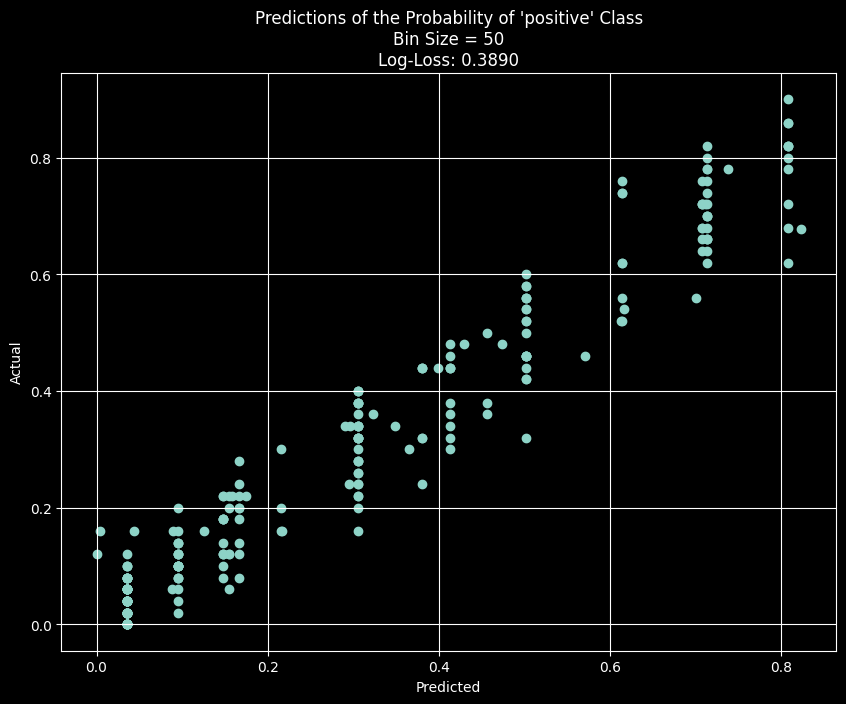

In [9]:
classifier = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="positive",
    impurity="entropy",
    maxBins=50,
    maxDepth=7,
    minInstancesPerNode=20
)
model = classifier.fit(learn_data_ps)

predictions = (
    model
    .transform(test_data_ps)
    .select(
        get_success_probability("probability").alias("positive")
    )
    .toPandas()
)
predictions["positive"] = np.clip(predictions["positive"], 1e-6, 1 - 1e-6)
predictions["negative"] = 1.0 - predictions["positive"]
predictions = predictions[["negative", "positive"]]

loss = get_log_loss(predictions, raw_test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, raw_test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

2026-03-05 18:54:43,709 - __main__ - INFO - Log-Loss: 0.3611                    
/tmp/ipykernel_17767/2405018113.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


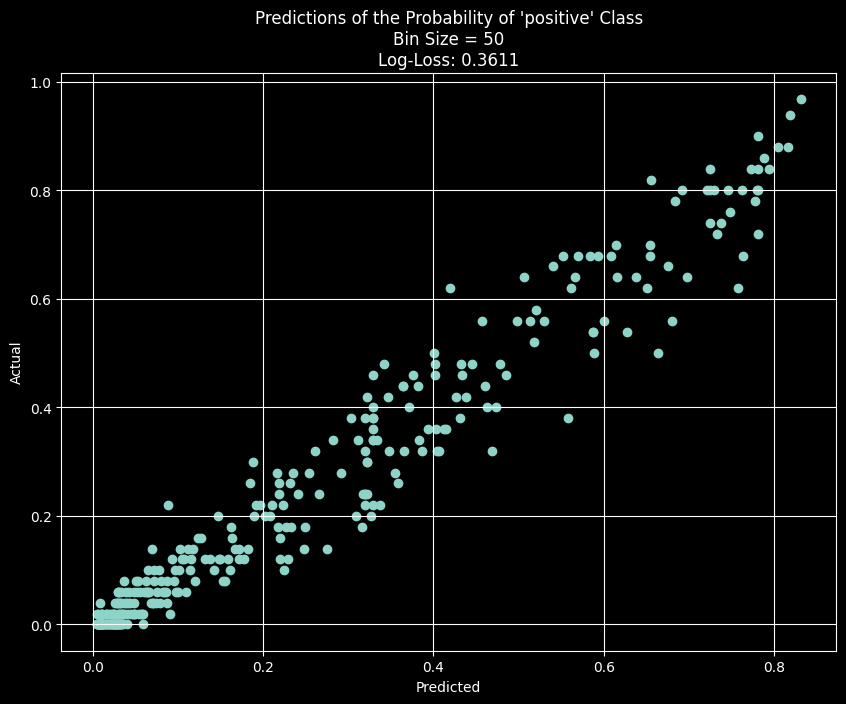

In [10]:
classifier = RandomForestClassifier(
    featuresCol="features",
    labelCol="positive",
    numTrees=100,
    impurity="entropy",
    maxBins=50,
    maxDepth=10
)
model = classifier.fit(learn_data_ps)

predictions = (
    model
    .transform(test_data_ps)
    .select(
        get_success_probability("probability").alias("positive")
    )
    .toPandas()
)
predictions["positive"] = np.clip(predictions["positive"], 1e-6, 1 - 1e-6)
predictions["negative"] = 1.0 - predictions["positive"]
predictions = predictions[["negative", "positive"]]

loss = get_log_loss(predictions, raw_test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, raw_test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

2026-03-05 18:55:27,445 - __main__ - INFO - Log-Loss: 0.3596                    
/tmp/ipykernel_17767/1899809054.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


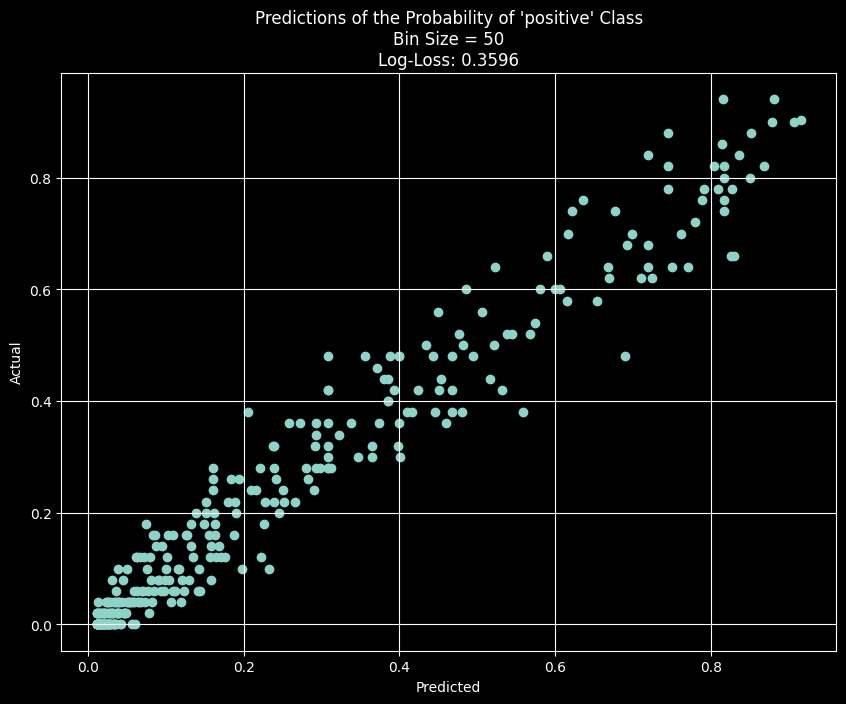

In [11]:
classifier = GBTClassifier(
    featuresCol="features",
    labelCol="positive",
    maxIter=100,
    stepSize=0.1,
    maxBins=50,
    maxDepth=3
)
model = classifier.fit(learn_data_ps)

predictions = (
    model
    .transform(test_data_ps)
    .select(
        get_success_probability("probability").alias("positive")
    )
    .toPandas()
)
predictions["positive"] = np.clip(predictions["positive"], 1e-6, 1 - 1e-6)
predictions["negative"] = 1.0 - predictions["positive"]
predictions = predictions[["negative", "positive"]]

loss = get_log_loss(predictions, raw_test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, raw_test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()